
---

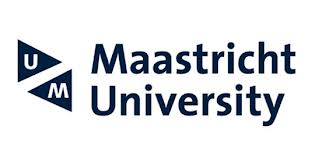


# Faculty of Science and Engineering — Department of Advanced Computing Sciences

# ANLP 2026-2027 — Assignment 2: Deep Learning for NLP

**Covers:** Tutorials 06 (PyTorch), 07 (Transformers), 08 (Encoder Models), 09 (Decoder Models), 10 (XAI), 11 (Fine-Tuning LLMs)

⏱️ **Estimated time:** 1.6 hours – 3.5 hours

By Jan Scholtes — Version 2026-2027

---

**Instructions:**
- This is a **graded assignment** worth 80 points
- You will build, fine-tune, and interpret a text classification pipeline using Transformers
- Each exercise builds on concepts from multiple tutorials
- Fill in the `# TODO` sections and write your answers where indicated
- Do **not** modify test cells
- Some cells require a GPU or may take a few minutes to run

**Time estimate:** ~4-5 hours

## Setup

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()


## Dataset: News Headlines

In [ ]:
# 30 news headlines with categories: 0=sports, 1=technology, 2=politics
headlines = [
    "Champions League final breaks viewership records across Europe",
    "Tennis star announces retirement after 20-year career on tour",
    "Olympic committee confirms new sports for 2028 Los Angeles Games",
    "Football transfer window sees record-breaking spending by top clubs",
    "Marathon runner sets new world record at Berlin race event",
    "Apple unveils new AI chip designed for on-device machine learning",
    "Cybersecurity breach exposes millions of user accounts worldwide",
    "Quantum computing startup raises billion-dollar funding round today",
    "Social media platform launches new content moderation AI tools",
    "Electric vehicle battery technology achieves major efficiency breakthrough",
    "Parliament votes on controversial immigration reform bill this week",
    "Trade negotiations between major economies stall over tariff disputes",
    "Supreme Court ruling reshapes environmental regulation enforcement nationwide",
    "Election polls show tight race in key battleground swing states",
    "International summit addresses global climate change policy framework",
    "Basketball playoffs deliver dramatic overtime victory for underdogs",
    "Startup develops revolutionary protein-folding AI prediction model",
    "Senate committee launches investigation into big tech monopoly practices",
    "Cricket world cup draws massive global television audience numbers",
    "New smartphone features satellite emergency communication capability today",
    "Prime minister faces confidence vote amid coalition government crisis",
    "Swimming federation updates doping testing protocols for competitions",
    "Robotics company demonstrates autonomous warehouse delivery drone system",
    "Foreign policy debate intensifies over military aid spending abroad",
    "Golf tournament postponed due to extreme weather warning conditions",
    "Cloud computing giant opens new European data center campus",
    "Opposition party proposes major healthcare system overhaul reform plan",
    "Rugby league introduces concussion protocol changes for player safety",
    "Artificial intelligence regulation bill passes first legislative reading",
    "Cycling team suspended following anti-doping investigation rule violations",
]

categories = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 2, 0]
cat_names = {0: "sports", 1: "technology", 2: "politics"}

print(f"Loaded {len(headlines)} headlines")
for cat_id, name in cat_names.items():
    count = categories.count(cat_id)
    print(f"  {name}: {count} headlines")

# Exercises

## Exercise A1: From Embeddings to Classification (20 points)

*Integrates: Tutorial 06 (PyTorch) + Tutorial 07 (Transformers)*

**a)** (12 points — code) Complete the steps below:
1. Tokenize all headlines using `bert-base-uncased` tokenizer
2. Extract `[CLS]` embeddings from BERT (no fine-tuning — just use the pre-trained model as a feature extractor)
3. Build a simple PyTorch classifier (`nn.Linear`) on top of the `[CLS]` embeddings
4. Train it for 50 epochs and store the losses in `epoch_losses`

**b)** (8 points — explanation) Why do we use the `[CLS]` token for classification? How does self-attention in BERT make this possible?

In [ ]:
from transformers import BertModel

# Step 1: Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased").to(device)
bert_model.eval()

# Step 2: Extract [CLS] embeddings (given — no gradient needed)
with torch.no_grad():
    all_embeddings = []
    for h in headlines:
        inputs = tokenizer(h, return_tensors="pt", truncation=True,
                          max_length=64, padding="max_length").to(device)
        outputs = bert_model(**inputs)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        all_embeddings.append(cls_emb.cpu())

X = torch.cat(all_embeddings, dim=0)  # shape: (30, 768)
y = torch.tensor(categories, dtype=torch.long)
print(f"Embeddings shape: {X.shape}")
print(f"Labels shape: {y.shape}")

In [ ]:
# Step 3 & 4: Build classifier and train
# TODO: create a nn.Linear layer (768 → 3 classes)
# TODO: define optimizer (Adam, lr=0.01) and loss function (CrossEntropyLoss)
# TODO: train for 50 epochs, store loss per epoch in epoch_losses
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# AUTO-GRADED TESTS (12 points)
# Do not modify this cell



### A1 Explanation (8 points — manually graded)

Why do we use the `[CLS]` token for classification? How does self-attention make this work? Answer the following:

1. What does the `[CLS]` token represent?
2. What is the role of self-attention in building the `[CLS]` representation?
3. Why not simply average all token embeddings instead?
4. What is a limitation of this approach (using BERT as a frozen feature extractor)?

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Encoder vs Decoder Models (20 points)

*Integrates: Tutorial 08 (Encoder Models) + Tutorial 09 (Decoder Models)*

**a)** (10 points — code) Compare a BERT-based classifier (encoder, `text-classification` pipeline) and a GPT-2 zero-shot approach (decoder) on the same 10 test headlines. Store results in the required format.

**b)** (10 points — explanation) Compare encoder and decoder architectures for classification tasks.

In [ ]:
# Encoder approach: BERT sentiment pipeline (given)
encoder_pipe = pipeline("zero-shot-classification",
                        model="facebook/bart-large-mnli",
                        device=0 if torch.cuda.is_available() else -1)

# Test headlines (subset)
test_headlines = headlines[:10]
test_labels = categories[:10]
candidate_labels = ["sports", "technology", "politics"]

# TODO: classify each test headline with encoder_pipe
# TODO: store results as list of dicts: {"headline": ..., "predicted": ..., "actual": ...}
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Decoder approach: GPT-2 with prompting
gpt2_pipe = pipeline("text-generation", model="gpt2", device=0 if torch.cuda.is_available() else -1,
                     max_new_tokens=5, pad_token_id=50256)

# TODO: for each test headline, construct a prompt and classify based on GPT-2's completion
# TODO: store results in decoder_results (same format as encoder_results)
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# AUTO-GRADED TESTS (10 points)
# Do not modify this cell



### A2 Explanation (10 points — manually graded)

Compare encoder and decoder models for text classification. Answer the following:

1. How do their architectures differ (encoder vs decoder)?
2. How does each model approach classification?
3. What are the strengths of each approach?
4. What are the weaknesses of each approach?
5. When would you use each one?
6. Which performed better on the headlines, and why? (2-3 sentences)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Fine-Tuning with LoRA (20 points)

*Integrates: Tutorial 11 (Fine-Tuning LLMs) + Tutorial 08 (Encoder Models)*

**a)** (12 points — code) Fine-tune a `distilbert-base-uncased` model on the headlines dataset using LoRA (from the `peft` library). Compare the number of trainable parameters with full fine-tuning.

**b)** (8 points — explanation) When is LoRA preferable to full fine-tuning?

In [ ]:
from transformers import TrainingArguments, Trainer
from datasets import Dataset

# Prepare dataset for HuggingFace Trainer
train_data = Dataset.from_dict({
    "text": headlines,
    "label": categories
})

# Tokenize
model_name = "distilbert-base-uncased"
ft_tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(examples):
    return ft_tokenizer(examples["text"], truncation=True, max_length=64, padding="max_length")

tokenized_data = train_data.map(tokenize_fn, batched=True)
tokenized_data.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print(f"Dataset: {len(tokenized_data)} samples, 3 classes")

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

# Load base model
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3
).to(device)

# Count full fine-tuning parameters
full_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
print(f"Full fine-tuning trainable params: {full_params:,}")

# TODO: Create LoRA config (target_modules=["q_lin", "v_lin"], r=8, lora_alpha=32)
# TODO: Apply LoRA to base model using get_peft_model
# TODO: Count and store trainable params as lora_params
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Train with LoRA
# TODO: define TrainingArguments (output_dir="./a2_lora", num_train_epochs=10,
#        per_device_train_batch_size=8, learning_rate=2e-4, logging_steps=5)
# TODO: create Trainer and train
# TODO: store training loss history in lora_losses
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# AUTO-GRADED TESTS (12 points)
# Do not modify this cell



### A3 Explanation (8 points — manually graded)

When is LoRA preferable to full fine-tuning? Answer the following:

1. How many parameters are trained in full fine-tuning vs. LoRA?
2. How do they compare in memory and compute cost?
3. What is the risk of catastrophic forgetting for each approach?
4. When would you prefer each approach?
5. How much parameter reduction did you achieve? What does `r=8` control? (2-3 sentences)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Model Interpretation (20 points)

*Integrates: Tutorial 10 (XAI for NLP) + Tutorial 07 (Transformers)*

**a)** (12 points — code) Use LIME to explain the predictions of the encoder pipeline from A2. For 3 headlines, generate explanations showing which words contribute most to the classification.

**b)** (8 points — explanation) Interpret the LIME results and discuss limitations.

In [ ]:
try:
    from lime.lime_text import LimeTextExplainer
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "-qq", "lime"])
    from lime.lime_text import LimeTextExplainer

# Wrapper function for LIME (must return probability array)
def predict_proba(texts):
    """Return class probabilities for a list of texts."""
    results = []
    for text in texts:
        output = encoder_pipe(text, candidate_labels, multi_label=False)
        # Map scores to fixed order: [sports, technology, politics]
        score_map = dict(zip(output["labels"], output["scores"]))
        probs = [score_map.get(cat, 0.0) for cat in candidate_labels]
        results.append(probs)
    return np.array(results)

explainer = LimeTextExplainer(class_names=candidate_labels)
print("LIME explainer ready")

In [ ]:
# TODO: explain 3 headlines (indices 0, 5, 10) using explainer.explain_instance
# TODO: for each, extract the top-5 contributing words
# TODO: store results in lime_explanations: list of dicts with
#        {"headline": str, "predicted": str, "top_words": list of (word, weight) tuples}
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# AUTO-GRADED TESTS (12 points)
# Do not modify this cell



### A4 Explanation (8 points — manually graded)

Interpret the LIME results:

1. For each of the 3 headlines, do the top contributing words make intuitive sense? Give a brief assessment for each. (3-4 sentences total)
2. What are 2 limitations of using LIME for NLP explanations? (2-3 sentences)
3. How does LIME relate to the attention mechanism in Transformers? Are they measuring the same thing? (2-3 sentences)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Summary

In this assignment you built a complete Deep Learning NLP pipeline:

1. **Feature Extraction** (T06+T07): BERT embeddings → PyTorch linear classifier
2. **Model Comparison** (T08+T09): Encoder (BART zero-shot) vs Decoder (GPT-2 prompting)
3. **Efficient Fine-Tuning** (T11): LoRA adapters on DistilBERT
4. **Explainability** (T10): LIME interpretations of model predictions

**Total: 80 points** (46 auto-graded + 34 manually graded)